In [2]:
import json
import pandas as pd

In [3]:
df = pd.read_csv("/DATA/DATANAS2/rhh25/Cellhit/data/drugs/drugs_info.csv")
df

,Drug Name,InchiKey,CID,Smiles
0,XYLOMETAZOLINE HCL,YGWFCQYETHJKNX-UHFFFAOYSA-N,5282386,CC1=CC(=CC(=C1CC2=NCCN2)C)C(C)(C)C.Cl
1,BAICALEIN,FXNFHKRTJBSTCS-UHFFFAOYSA-N,5281605,C1=CC=C(C=C1)C2=CC(=O)C3=C(O2)C=C(C(=C3O)O)O
2,CHEMBL3348974,TTZHDVOVKQGIBA-SWMKZBNESA-N,73265383,CC(C)OC(=O)C(C)NP(=O)(OCC1C(C(C(O1)N2C=CC(=O)N...
3,AC-261066,HSAOETBFVAWNRP-UHFFFAOYSA-N,11530459,CCCCOCCOC1=C(SC(=N1)C2=CC(=C(C=C2)C(=O)O)F)C
4,SILDENAFIL,BNRNXUUZRGQAQC-UHFFFAOYSA-N,135398744,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...
...,...,...,...,...
4145,NCGC00179454-04,GAOZTHIDHYLHMS-XGDPBVOXSA-M,73265358,CCC1(CCC(O1)C2(CCC3(O2)CC(C(C(O3)C(C)C(C(C)C(=...
4146,5-FLUORO-2\'-DEOXYURIDINE,BNMDIVHTOIOYFX-UHFFFAOYSA-N,44403842,C1C(C(OC1N2CC(C(=O)NC2=O)F)CO)O
4147,SCHEMBL16177287,IENLGMOXAQMNEH-UHFFFAOYSA-N,76189046,CC(CN(C)C)OC1=NC(=CN=C1C#N)NC2=NC=C(C(=C2)OC)C...
4148,WO2016044770,SWXCHCQCWFXILM-UHFFFAOYSA-N,134327298,CC(C(F)(F)F)N(CC1=CC=C(C=C1)F)C(=O)CN2C(=O)C3(...


In [4]:
tartget_path = '/DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/drugcomb_target_df.csv'
mapping_path = '/villa/rhh25/Cellhit/bindingdb_protein_mapping_results.csv'


In [12]:
target_df = pd.read_csv(tartget_path)
mapping_df = pd.read_csv(mapping_path)
mapping_df.rename({'STRING_id':'Protein', 'Target Name':'Name', 'STRING_preferred_name':'Coded Gene'}, axis=1, inplace=True)
protein_info = target_df.merge(mapping_df, on='Protein', how='inner')[['Protein', 'Name', 'Coded Gene']].drop_duplicates(subset=['Protein','Coded Gene']).reset_index(drop=True)  



In [16]:
mapping_df.Protein.nunique()


1994

In [14]:
target_df

,Drug Name,Protein
0,BAICALEIN,9606.ENSP00000354612
1,Celecoxib,9606.ENSP00000354612
2,SULFASALAZINE,9606.ENSP00000354612
3,PRANOPROFEN,9606.ENSP00000354612
4,ROFECOXIB,9606.ENSP00000354612
...,...,...
60022,211915-06-9,9606.ENSP00000341045
60023,211915-06-9,9606.ENSP00000346768
60024,211915-06-9,9606.ENSP00000369822
60025,211915-06-9,9606.ENSP00000304811


In [11]:
protein_info

,Protein,Name,Coded Gene
0,9606.ENSP00000354612,Prostaglandin G/H synthase 1,PTGS1
1,9606.ENSP00000264382,"Sucrase-isomaltase, intestinal",SI
2,9606.ENSP00000397239,Lysine-specific demethylase 4E,KDM4E
3,9606.ENSP00000378699,Cyclin-dependent kinase 1,CDK1
4,9606.ENSP00000337949,5-hydroxytryptamine receptor 7,HTR7
...,...,...,...
1552,9606.ENSP00000226730,Interleukin-2,IL2
1553,9606.ENSP00000263182,Gamma-butyrobetaine dioxygenase,BBOX1
1554,9606.ENSP00000302232,Alpha-ketoglutarate-dependent dioxygenase alkB...,ALKBH3
1555,9606.ENSP00000398181,DNA oxidative demethylase ALKBH2,ALKBH2


In [8]:
mapping_df

,Name,Protein,Coded Gene
0,17-beta-hydroxysteroid dehydrogenase type 3,9606.ENSP00000364412,HSD17B3
1,1-deoxy-D-xylulose 5-phosphate reductoisomerase,511145.b0173,dxr
2,Aurora kinase B,7955.ENSDARP00000054822,aurkb
3,Polyunsaturated fatty acid 5-lipoxygenase,7955.ENSDARP00000074335,alox5a
4,Prostaglandin G/H synthase 1,9606.ENSP00000354612,PTGS1
...,...,...,...
2046,Somatostatin receptor type 2,9606.ENSP00000350198,SSTR2
2047,Fanconi anemia group J protein,9606.ENSP00000259008,BRIP1
2048,Complement C1r subcomponent,9606.ENSP00000444271,C1R
2049,Peptidyl-prolyl cis-trans isomerase FKBP5,9606.ENSP00000444810,FKBP5


In [7]:
protein_info

,Protein,Name,Coded Gene
0,9606.ENSP00000354612,Prostaglandin G/H synthase 1,PTGS1
1,9606.ENSP00000264382,"Sucrase-isomaltase, intestinal",SI
2,9606.ENSP00000397239,Lysine-specific demethylase 4E,KDM4E
3,9606.ENSP00000378699,Cyclin-dependent kinase 1,CDK1
4,9606.ENSP00000337949,5-hydroxytryptamine receptor 7,HTR7
...,...,...,...
1552,9606.ENSP00000226730,Interleukin-2,IL2
1553,9606.ENSP00000263182,Gamma-butyrobetaine dioxygenase,BBOX1
1554,9606.ENSP00000302232,Alpha-ketoglutarate-dependent dioxygenase alkB...,ALKBH3
1555,9606.ENSP00000398181,DNA oxidative demethylase ALKBH2,ALKBH2


In [6]:
protein_info.rename(columns={'Protein':'Protein ID', 'Name':'Protein Name'}, inplace=True)
protein_info

,Protein ID,Protein Name,Coded Gene
0,9606.ENSP00000354612,Prostaglandin G/H synthase 1,PTGS1
1,9606.ENSP00000264382,"Sucrase-isomaltase, intestinal",SI
2,9606.ENSP00000397239,Lysine-specific demethylase 4E,KDM4E
3,9606.ENSP00000378699,Cyclin-dependent kinase 1,CDK1
4,9606.ENSP00000337949,5-hydroxytryptamine receptor 7,HTR7
...,...,...,...
1552,9606.ENSP00000226730,Interleukin-2,IL2
1553,9606.ENSP00000263182,Gamma-butyrobetaine dioxygenase,BBOX1
1554,9606.ENSP00000302232,Alpha-ketoglutarate-dependent dioxygenase alkB...,ALKBH3
1555,9606.ENSP00000398181,DNA oxidative demethylase ALKBH2,ALKBH2


In [ ]:
#protein_info.to_csv('/DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/protein_info.csv', index=False)

In [49]:
target_protein_info = target_df.merge(mapping_df, on='Protein', how='inner')
target_protein_info_gp = target_protein_info.groupby('Drug Name').agg('count').reset_index()[['Drug Name', 'Protein']]
target_protein_info_gp

,Drug Name,Protein
0,(+)-BICUCULLINE,1
1,(+)-JQ1,7
2,(+)-USNIACIN,1
3,(+)-Usniacin,1
4,(-)-BLEBBISTATIN,1
...,...,...
3945,voxtalisib,5
3946,warfarin,10
3947,xylometazoline,14
3948,"{(3r,4r)-4-Methyl-3-[methyl(7h-Pyrrolo[2,3-D]p...",1


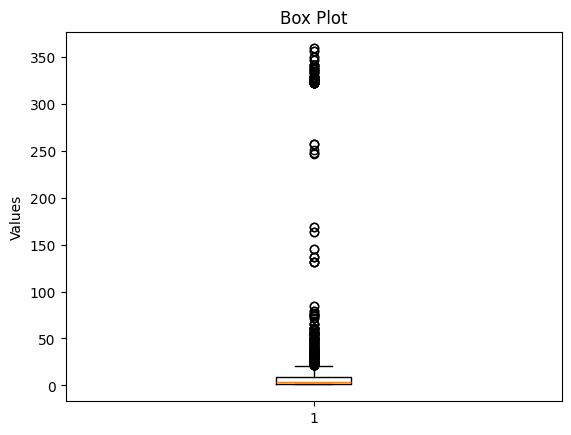

In [48]:

count_lst = target_protein_info.groupby('Drug Name').agg('count').reset_index()['Protein'].tolist()

import matplotlib.pyplot as plt

plt.boxplot(count_lst)
plt.title("Box Plot")
plt.ylabel("Values")

plt.show()

Mot Drugs around 6 to 100, but in here I take the upper bound to the outlier: 25->100

In [60]:
elite_random_drugs = target_protein_info_gp[(target_protein_info_gp['Protein'] >= 15) & (target_protein_info_gp['Protein'] <= 100)].sample(n=10, random_state=42)

elite_groundtruth_df = target_df[target_df['Drug Name'].isin(elite_random_drugs['Drug Name'].tolist())].groupby('Drug Name').agg(list).reset_index()
elite_groundtruth_df.rename(columns={'Protein': 'Proteins'}, inplace=True)
elite_groundtruth_df

,Drug Name,Proteins
0,AP-26113,"[9606.ENSP00000241453, 9606.ENSP00000462468, 9..."
1,AZD1775,"[9606.ENSP00000498939, 9606.ENSP00000300093, 9..."
2,CHRYSIN,"[9606.ENSP00000354612, 9606.ENSP00000362463, 9..."
3,Dipyridamole,"[9606.ENSP00000478255, 9606.ENSP00000347046, 9..."
4,KAEMPFEROL,"[9606.ENSP00000354612, 9606.ENSP00000362463, 9..."
5,LANSOPRAZOLE,"[9606.ENSP00000498939, 9606.ENSP00000478255, 9..."
6,LY294002,"[9606.ENSP00000300093, 9606.ENSP00000274289, 9..."
7,Leflunomide,"[9606.ENSP00000497931, 9606.ENSP00000494609, 9..."
8,Primidone,"[9606.ENSP00000497931, 9606.ENSP00000494609, 9..."
9,staurosporine,"[9606.ENSP00000263923, 9606.ENSP00000373700, 9..."


In [67]:
elite_groundtruth_df.to_csv('/DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/elite_drug_target_groundtruth.csv', index=False)

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('/DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/elite_drug_target_groundtruth.csv')
df